In [22]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import trange
import matplotlib.pyplot as plt
import random
from typing import Tuple

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
np.random.seed(0); torch.manual_seed(0); random.seed(0)

In [24]:
NUM_MESSAGES = 4
BATCH_SIZE = 512
EPOCHS = 1000
LR_ACTOR = 3e-4
LR_CRITIC = 3e-4
RECEIVER_LR = 1e-3
POLICY_STD_INIT = 0.4
POLICY_STD_MIN = 0.05
STD_DECAY = 0.997
SNR_DB = 10

In [25]:
QUANTIZE = True
Q_STEP = 0.15

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

In [26]:
def ebno_to_sigma_db(ebno_db):
    ebno = 10 ** (ebno_db / 10)
    sigma = math.sqrt(1 / (2 * ebno))
    return sigma

def add_awgn(x, sigma):
    return x + sigma * torch.randn_like(x)

def quantize(x, step):
    return torch.round(x / step) * step

In [27]:
class Actor(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(NUM_MESSAGES, 16)
        self.fc = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )
    def forward(self, msg):
        h = self.embed(msg)
        return self.fc(h)

In [28]:

class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(NUM_MESSAGES, 16)
        self.fc = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, msg):
        h = self.embed(msg)
        return self.fc(h)

In [29]:
class Receiver(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, NUM_MESSAGES)
        )
    def forward(self, x):
        return self.fc(x)

In [30]:
def evaluate_bler(actor, receiver, snr_db):
    actor.eval(); receiver.eval()
    with torch.no_grad():
        N = 3000
        msgs = torch.randint(0, NUM_MESSAGES, (N,), device=device)
        means = actor(msgs)
        sigma = ebno_to_sigma_db(snr_db)
        rx = add_awgn(means, sigma)
        if QUANTIZE: rx = quantize(rx, Q_STEP)
        logits = receiver(rx)
        preds = logits.argmax(dim=1)
        return (preds != msgs).float().mean().item()

In [31]:
def main():

    actor = Actor().to(device)
    critic = Critic().to(device)
    receiver = Receiver().to(device)

    opt_actor = optim.Adam(actor.parameters(), lr=LR_ACTOR)
    opt_critic = optim.Adam(critic.parameters(), lr=LR_CRITIC)
    opt_rx = optim.Adam(receiver.parameters(), lr=RECEIVER_LR)

    sigma = ebno_to_sigma_db(SNR_DB)
    ce_loss = nn.CrossEntropyLoss()

    policy_std = POLICY_STD_INIT

    rewards_hist = []
    bler_hist = []

    for ep in trange(EPOCHS):

        msgs = torch.randint(0, NUM_MESSAGES, (BATCH_SIZE,), device=device)

        # -------------------- ACTOR FORWARD --------------------
        means = actor(msgs)                       # (B,2)
        eps = torch.randn_like(means)
        actions = means + policy_std * eps        # exploration

        # -------------------- CHANNEL ---------------------------
        rx = add_awgn(actions, sigma)
        if QUANTIZE:
            rx = quantize(rx, Q_STEP)

        # -------------------- RECEIVER --------------------------
        logits = receiver(rx)
        loss_rx = ce_loss(logits, msgs)

        # train receiver
        opt_rx.zero_grad()
        loss_rx.backward(retain_graph=True)
        opt_rx.step()

        # reward = negative CE loss
        rewards = -loss_rx.detach()

        # ----------------- CRITIC UPDATE ------------------------
        values = critic(msgs).squeeze(1)
        critic_loss = ((values - rewards) ** 2).mean()

        opt_critic.zero_grad()
        critic_loss.backward()
        opt_critic.step()

        # ----------------- ADVANTAGE ----------------------------
        with torch.no_grad():
            adv = rewards - values.detach()

        # ----------------- ACTOR UPDATE --------------------------
        log_prob = -0.5 * ((actions - means)**2 / (policy_std**2)).sum(dim=1)
        actor_loss = -(log_prob * adv).mean()

        opt_actor.zero_grad()
        actor_loss.backward()
        opt_actor.step()

        # ----------------- LOGGING ------------------------------
        rewards_hist.append(rewards.item())

        if ep % 10 == 0:
            bler = evaluate_bler(actor, receiver, SNR_DB)
            bler_hist.append((ep, bler))
            print(f"Epoch {ep} | CE={loss_rx.item():.4f} | BLER={bler:.4f}")

        # decay exploration
        policy_std = max(POLICY_STD_MIN, policy_std * STD_DECAY)

    # Reward curve
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.plot(rewards_hist)
    plt.title("Reward")
    plt.xlabel("Epoch")

    # BLER curve
    plt.subplot(1,3,2)
    xs = [e for e,_ in bler_hist]
    ys = [b for _,b in bler_hist]
    plt.plot(xs, ys, marker='o')
    plt.title("BLER @ 10 dB")

    # Learned constellation
    plt.subplot(1,3,3)
    actor.eval()
    with torch.no_grad():
        m = torch.arange(NUM_MESSAGES, device=device)
        points = actor(m).cpu().numpy()
        plt.scatter(points[:,0], points[:,1])
        for i, (x,y) in enumerate(points):
            plt.text(x+0.02, y+0.02, str(i))
        plt.title("Learned Constellation")
        plt.gca().set_aspect('equal')

    plt.tight_layout()
    plt.show()

  5%|▍         | 47/1000 [00:00<00:04, 228.70it/s]

Epoch 0 | CE=1.4606 | BLER=0.7527
Epoch 10 | CE=1.4164 | BLER=0.7440
Epoch 20 | CE=1.3833 | BLER=0.6840
Epoch 30 | CE=1.3543 | BLER=0.5247
Epoch 40 | CE=1.3271 | BLER=0.3680


  7%|▋         | 70/1000 [00:00<00:04, 226.60it/s]

Epoch 50 | CE=1.3017 | BLER=0.3257
Epoch 60 | CE=1.2892 | BLER=0.3370
Epoch 70 | CE=1.2534 | BLER=0.2830
Epoch 80 | CE=1.2349 | BLER=0.2643


 11%|█▏        | 113/1000 [00:00<00:05, 171.48it/s]

...

Epoch 870 | CE=0.6307 | BLER=0.2383
Epoch 880 | CE=0.5558 | BLER=0.2210
Epoch 890 | CE=0.5408 | BLER=0.2297
Epoch 900 | CE=0.5423 | BLER=0.2290
Epoch 910 | CE=0.5855 | BLER=0.2450


 96%|█████████▌| 962/1000 [00:05<00:00, 217.65it/s]

Epoch 920 | CE=0.6004 | BLER=0.2350
Epoch 930 | CE=0.5479 | BLER=0.2340
Epoch 940 | CE=0.5952 | BLER=0.2403
Epoch 950 | CE=0.6004 | BLER=0.2430
Epoch 960 | CE=0.5297 | BLER=0.2427


100%|██████████| 1000/1000 [00:05<00:00, 183.26it/s]


Epoch 970 | CE=0.5518 | BLER=0.2403
Epoch 980 | CE=0.5529 | BLER=0.2287
Epoch 990 | CE=0.5898 | BLER=0.2340


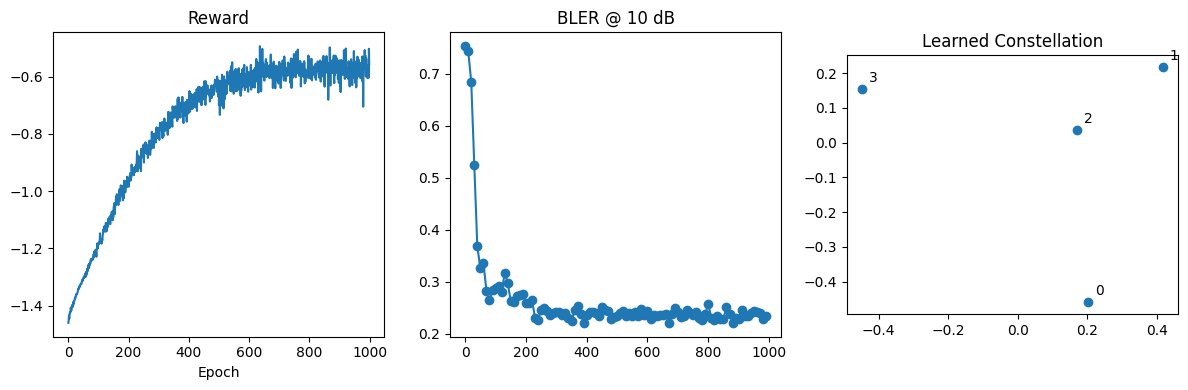

In [32]:
main()